### Import Necessary Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE


### Setup Data

In [2]:
df = pd.read_csv('phnom_penh_weather_processed.csv')

### Handling Imbalance Dataset

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=100, # number of trees in the forest
    # class_weight='balanced', # uncomment this line if you want to train the model using class_weight instead of SMOTE
    random_state=42
)

### drop redundant features
- Based on the heatmap in rainfall_EDA, `temp_diff` and `vapour_pressure_deficit` 
  have a correlation of 0.99, meaning they are nearly identical in information. 
  Keeping both adds no new signal to the model, so `temp_diff` was dropped to 
  reduce multicollinearity.


### Drop weather_code
- weather_code has a very high correlation of 0.95 with rain_class (our target).

In [4]:
df_model = df.drop(columns=['temp_diff', 'weather_code'])

### Separate features and target

In [5]:
X = df_model.drop(columns=['rain_class'])
y = df_model['rain_class']

### Stratified Train/Test Split
- This ensures that both the train and test sets have the **same proportion** 
  of rain vs no-rain, rather than splitting randomly.
- A random 80/20 split might accidentally contain more no-rain samples in 
  training, causing the model to be biased toward predicting no rain.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y        # ensures same rain/no-rain proportion
)

# Verify the split proportion
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("Test distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 rain_class
0    0.763344
1    0.121502
2    0.115153
Name: proportion, dtype: float64
Test distribution:
 rain_class
0    0.763334
1    0.121557
2    0.115109
Name: proportion, dtype: float64


### Model Training Using SMOTE

In [7]:
# Add this before training
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Change fit to use resampled data
random_forest_model.fit(X_train_resampled, y_train_resampled)

# Predict stays the same (always use original X_test)
y_pred = random_forest_model.predict(X_test)

### Model Training Using Class Weight

In [37]:
# Train
random_forest_model.fit(X_train, y_train)

# Predict
y_pred = random_forest_model.predict(X_test)

### Model Evaluation Using F1 Score

              precision    recall  f1-score   support

     No Rain       0.94      0.90      0.92      9589
  Light Rain       0.45      0.54      0.49      1527
  Heavy Rain       0.71      0.74      0.72      1446

    accuracy                           0.84     12562
   macro avg       0.70      0.73      0.71     12562
weighted avg       0.85      0.84      0.85     12562



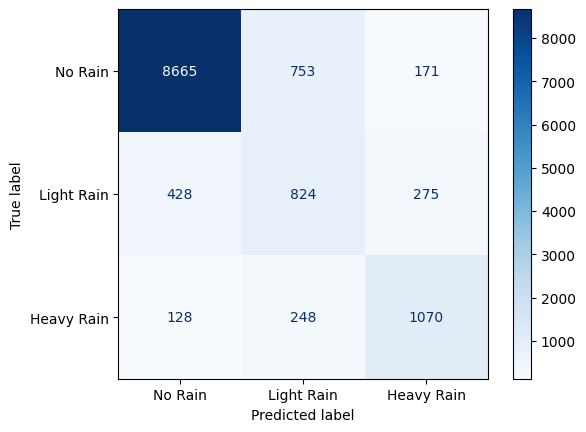

In [8]:
# F1 Score
print(classification_report(y_test, y_pred, 
      target_names=['No Rain', 'Light Rain', 'Heavy Rain']))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Rain', 'Light Rain', 'Heavy Rain'],
    cmap='Blues'
)

In [42]:
df.groupby('rain_class').mean().T

rain_class,0,1,2
temperature_2m,0.457267,0.484225,0.417485
relative_humidity_2m,0.642237,0.713710,0.807529
dew_point_2m,0.504913,0.678517,0.693569
apparent_temperature,0.482578,0.588357,0.495974
weather_code,0.032553,0.784615,0.863385
pressure_msl,0.521682,0.461378,0.421539
surface_pressure,0.496303,0.450823,0.420413
cloud_cover,0.695977,0.859341,0.954479
cloud_cover_low,0.179344,0.463007,0.506863
cloud_cover_mid,0.210180,0.411402,0.623966
